In [1]:
# ============================================
# CELL 1 — IMPORT LIBRARIES & BASIC SETUP
# Financial Stress Prediction — July Starter
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

# Display settings
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

# Plot settings
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True

print("Libraries imported successfully.")
print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)

Libraries imported successfully.
Pandas version: 2.2.2
NumPy version: 2.0.2


In [7]:
from google.colab import files

uploaded = files.upload()

Saving test_cleaned.csv to test_cleaned (1).csv
Saving train_cleaned.csv to train_cleaned.csv


In [8]:
# ============================================
# CELL 3 — LOAD CLEANED DATASETS
# ============================================

train = pd.read_csv("train_cleaned.csv")
test = pd.read_csv("test_cleaned.csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (40000, 184)
Test shape: (30000, 183)


In [9]:
# ============================================
# CELL 4 — BASIC DATASET VERIFICATION
# ============================================

print("TRAIN")
print("Rows:", train.shape[0])
print("Columns:", train.shape[1])

print("\nTEST")
print("Rows:", test.shape[0])
print("Columns:", test.shape[1])

print("\nTarget column:")
print("liquidity_stress_next_30d" in train.columns)

print("\nMissing values in Train:", train.isna().sum().sum())
print("Missing values in Test:", test.isna().sum().sum())

print("\nDuplicate rows in Train:", train.duplicated().sum())
print("Duplicate rows in Test:", test.duplicated().sum())

TRAIN
Rows: 40000
Columns: 184

TEST
Rows: 30000
Columns: 183

Target column:
True

Missing values in Train: 0
Missing values in Test: 0

Duplicate rows in Train: 0
Duplicate rows in Test: 0


Target Distribution:
liquidity_stress_next_30d
0    34000
1     6000
Name: count, dtype: int64

Target Percentage:
liquidity_stress_next_30d
0   85.0000
1   15.0000
Name: proportion, dtype: float64


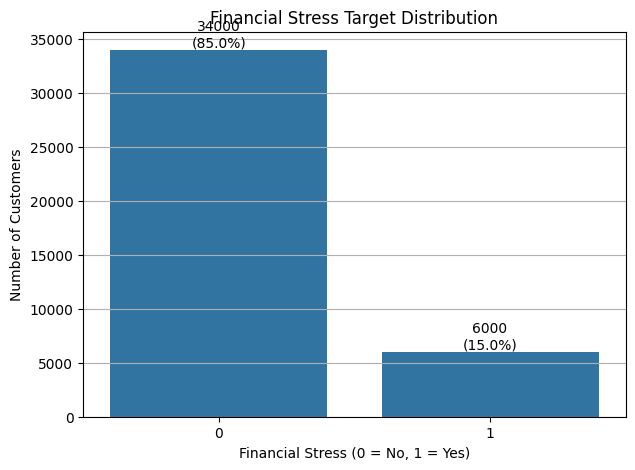

In [10]:
# ============================================
# CELL 5 — TARGET DISTRIBUTION
# ============================================

target_col = "liquidity_stress_next_30d"

target_counts = train[target_col].value_counts().sort_index()
target_percent = train[target_col].value_counts(normalize=True).sort_index() * 100

print("Target Distribution:")
print(target_counts)

print("\nTarget Percentage:")
print(target_percent.round(2))

# Visualization
plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=train,
    x=target_col
)

plt.title("Financial Stress Target Distribution")
plt.xlabel("Financial Stress (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")

# Add percentages on bars
total = len(train)

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[
            f"{int(v)}\n({v/total*100:.1f}%)"
            for v in container.datavalues
        ]
    )

plt.show()

In [11]:
# ============================================
# CELL 6 — CATEGORICAL FEATURES VS TARGET
# ============================================

categorical_cols = train.select_dtypes(include=["object", "category"]).columns.tolist()

# Remove ID because it is an identifier, not a meaningful category
categorical_cols = [col for col in categorical_cols if col != "ID"]

print("Categorical features:")
for col in categorical_cols:
    print("-", col)

print("\nNumber of categorical features:", len(categorical_cols))

Categorical features:
- gender
- region
- smartphone
- segment
- earning_pattern

Number of categorical features: 5


In [12]:
# ============================================
# CELL 7 — CATEGORY vs FINANCIAL STRESS
# ============================================

for col in categorical_cols:
    print(f"\n{'='*60}")
    print(f"{col}")
    print(f"{'='*60}")

    stress_rate = (
        train.groupby(col)[target_col]
        .agg(["count", "mean"])
        .rename(columns={"mean": "stress_rate"})
    )

    stress_rate["stress_rate"] *= 100

    print(stress_rate.sort_values("stress_rate", ascending=False).round(2))


gender
        count  stress_rate
gender                    
M       16092      15.3200
F       23908      14.7900

region
                            count  stress_rate
region                                        
Southern Highlands           7280      15.4900
Western Zone                 4536      15.4100
Northern Highlands           6412      15.3300
Coastal & Eastern Corridor   8776      14.8500
Lake Zone (Northwest)        5368      14.7900
Central Zone                 5044      14.7900
Islander                     2584      13.4300

smartphone
            count  stress_rate
smartphone                    
Yes         21956      15.0100
No          18044      14.9900

segment
         count  stress_rate
segment                    
HVC       3736      19.0300
LVC      15732      17.2300
MVC      20532      12.5600

earning_pattern
                  count  stress_rate
earning_pattern                     
Weekly Earner     24116      15.1800
Irregular Earner   6040      15.1000
Mon

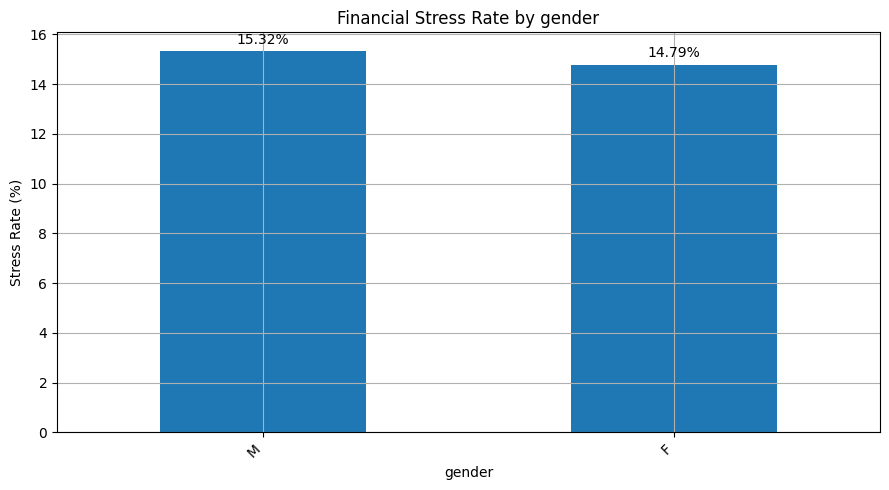

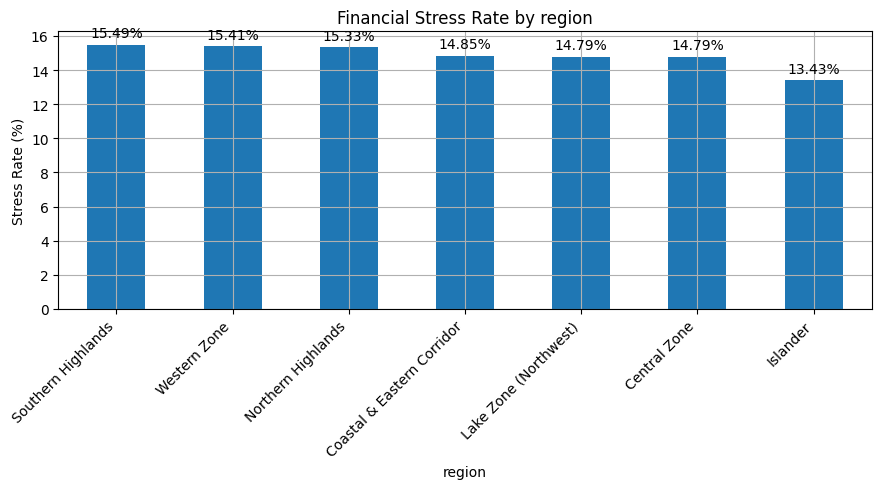

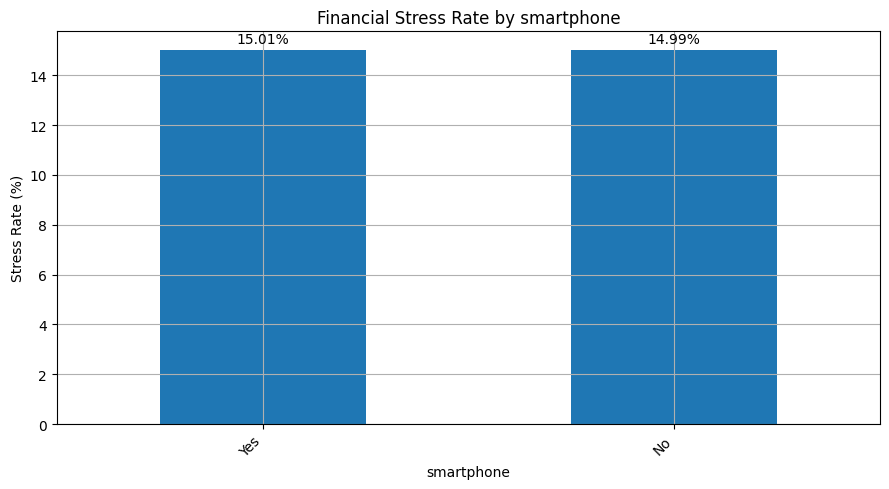

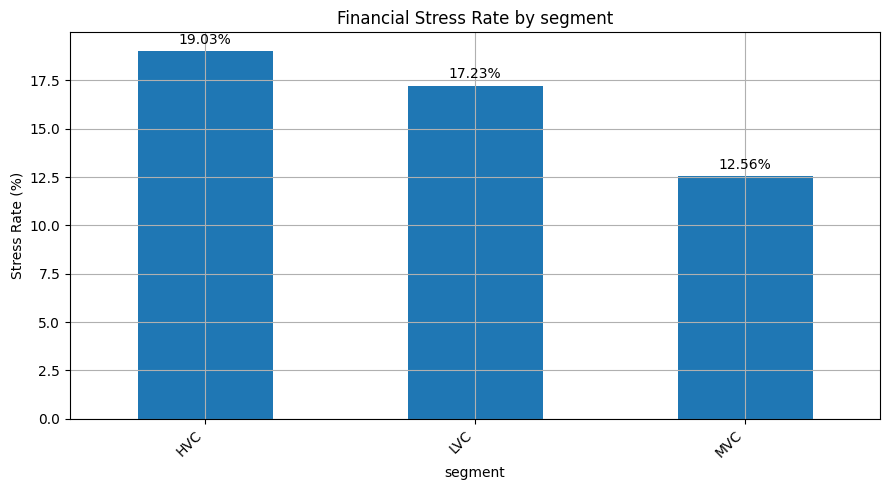

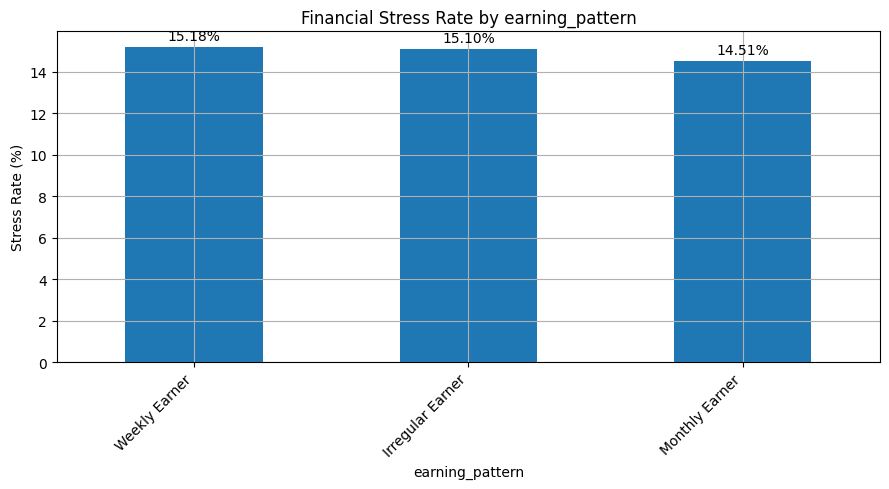

In [13]:
# ============================================
# CELL 8 — VISUALIZE CATEGORICAL STRESS RATES
# ============================================

for col in categorical_cols:

    stress_rate = (
        train.groupby(col)[target_col]
        .mean()
        .sort_values(ascending=False) * 100
    )

    plt.figure(figsize=(9, 5))

    ax = stress_rate.plot(kind="bar")

    plt.title(f"Financial Stress Rate by {col}")
    plt.xlabel(col)
    plt.ylabel("Stress Rate (%)")
    plt.xticks(rotation=45, ha="right")

    # Add values above bars
    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%.2f%%",
            padding=3
        )

    plt.tight_layout()
    plt.show()

In [14]:
# ============================================
# CELL 9 — IDENTIFY FINANCIAL FEATURE GROUPS
# ============================================

# Balance features
balance_cols = [
    col for col in train.columns
    if col.startswith("m") and "balance" in col.lower()
]

# Activity feature
activity_cols = [
    col for col in train.columns
    if "activity" in col.lower()
]

# Transaction-related features
transaction_keywords = [
    "paybill",
    "merchantpay",
    "transfer_from_bank",
    "mm_send",
    "received",
    "deposit",
    "withdraw"
]

transaction_cols = [
    col for col in train.columns
    if any(keyword in col.lower() for keyword in transaction_keywords)
]

print("Balance features:")
print(balance_cols)

print("\nActivity features:")
print(activity_cols)

print("\nNumber of transaction features:", len(transaction_cols))

Balance features:
[]

Activity features:
['x_90_d_activity_rate']

Number of transaction features: 168


In [15]:
# ============================================
# CELL 10 — FIND MONTHLY BALANCE COLUMNS
# ============================================

# Show columns containing "bal"
balance_candidates = [
    col for col in train.columns
    if "bal" in col.lower()
]

print("Possible balance columns:")
for col in balance_candidates:
    print(col)

print("\nNumber of possible balance columns:", len(balance_candidates))

Possible balance columns:
m1_daily_avg_bal
m2_daily_avg_bal
m3_daily_avg_bal
m4_daily_avg_bal
m5_daily_avg_bal
m6_daily_avg_bal

Number of possible balance columns: 6


In [16]:
# ============================================
# CELL 11 — MONTHLY BALANCE VS TARGET
# ============================================

balance_cols = [
    "m1_daily_avg_bal",
    "m2_daily_avg_bal",
    "m3_daily_avg_bal",
    "m4_daily_avg_bal",
    "m5_daily_avg_bal",
    "m6_daily_avg_bal"
]

balance_summary = train.groupby(target_col)[balance_cols].mean().T

balance_summary.columns = ["No Stress (0)", "Stress (1)"]

print(balance_summary.round(2))

                  No Stress (0)  Stress (1)
m1_daily_avg_bal    14,798.9800 14,034.5700
m2_daily_avg_bal    14,705.5500 14,068.6200
m3_daily_avg_bal    14,763.9500 13,901.6300
m4_daily_avg_bal    13,749.7800 20,162.5800
m5_daily_avg_bal    13,807.8600 20,488.7700
m6_daily_avg_bal    13,623.4800 20,694.1200


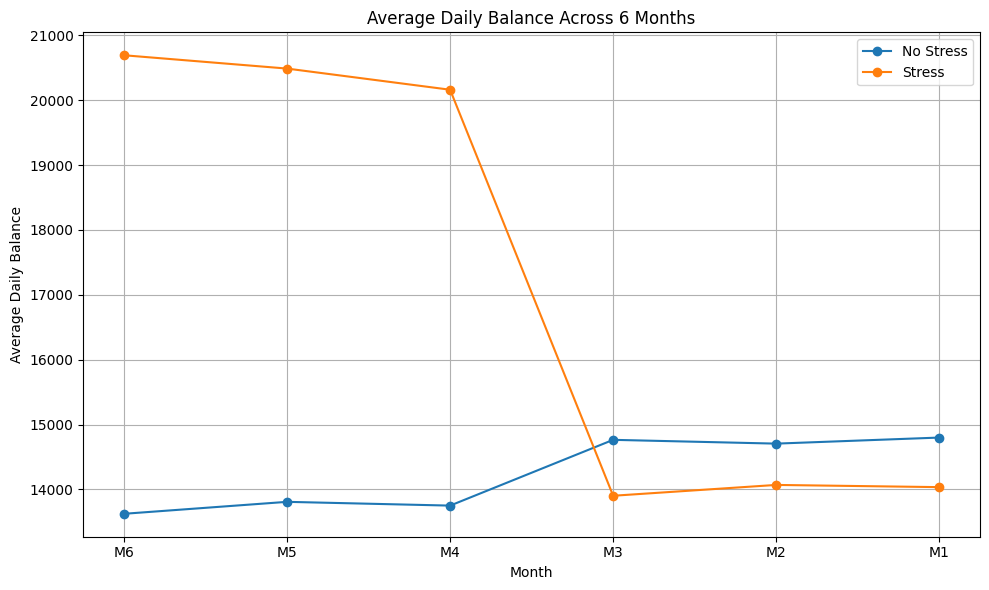

In [17]:
# Plot average balance across the six months

plt.figure(figsize=(10, 6))

months = ["M6", "M5", "M4", "M3", "M2", "M1"]

plt.plot(
    months,
    balance_summary["No Stress (0)"].values[::-1],
    marker="o",
    label="No Stress"
)

plt.plot(
    months,
    balance_summary["Stress (1)"].values[::-1],
    marker="o",
    label="Stress"
)

plt.title("Average Daily Balance Across 6 Months")
plt.xlabel("Month")
plt.ylabel("Average Daily Balance")
plt.legend()

plt.tight_layout()
plt.show()

In [18]:
# ============================================
# CELL 12 — BALANCE DISTRIBUTION BY TARGET
# ============================================

# Compare median balance as well as mean
balance_stats = train.groupby(target_col)[balance_cols].agg(
    ["mean", "median", "std"]
)

pd.set_option("display.max_columns", 50)

print(balance_stats.round(2))

                          m1_daily_avg_bal                         \
                                      mean     median         std   
liquidity_stress_next_30d                                           
0                              14,798.9800 5,412.7200 32,695.1000   
1                              14,034.5700 3,366.2800 32,982.4000   

                          m2_daily_avg_bal                         \
                                      mean     median         std   
liquidity_stress_next_30d                                           
0                              14,705.5500 5,342.0100 32,060.7100   
1                              14,068.6200 3,443.0100 33,302.3000   

                          m3_daily_avg_bal                         \
                                      mean     median         std   
liquidity_stress_next_30d                                           
0                              14,763.9500 5,386.6700 32,515.4000   
1                              1

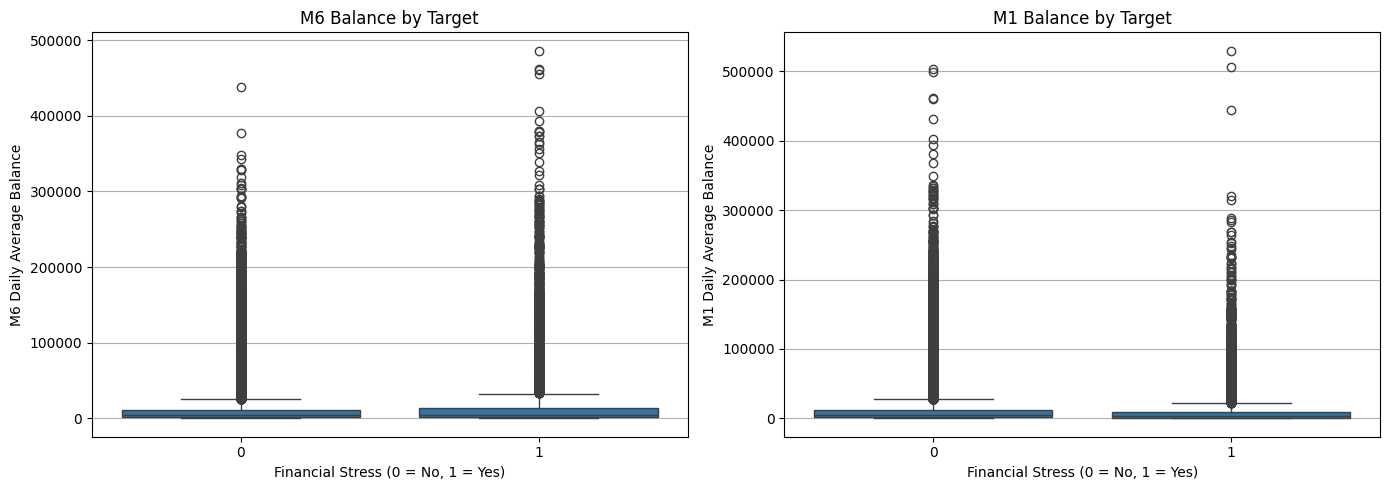

In [19]:
# Compare M6 and M1 distributions

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(
    data=train,
    x=target_col,
    y="m6_daily_avg_bal",
    ax=axes[0]
)

axes[0].set_title("M6 Balance by Target")
axes[0].set_xlabel("Financial Stress (0 = No, 1 = Yes)")
axes[0].set_ylabel("M6 Daily Average Balance")

sns.boxplot(
    data=train,
    x=target_col,
    y="m1_daily_avg_bal",
    ax=axes[1]
)

axes[1].set_title("M1 Balance by Target")
axes[1].set_xlabel("Financial Stress (0 = No, 1 = Yes)")
axes[1].set_ylabel("M1 Daily Average Balance")

plt.tight_layout()
plt.show()

In [20]:
# ============================================
# CELL 13 — ROBUST BALANCE DISTRIBUTION
# ============================================

quantiles = train.groupby(target_col)[balance_cols].quantile(
    [0.25, 0.50, 0.75, 0.90]
)

print(quantiles.round(2))

                                  m1_daily_avg_bal  m2_daily_avg_bal  \
liquidity_stress_next_30d                                              
0                         0.2500        1,518.7900        1,522.5400   
                          0.5000        5,412.7200        5,342.0100   
                          0.7500       11,847.6800       11,792.0700   
                          0.9000       24,088.9600       24,194.0100   
1                         0.2500        1,132.6300        1,104.8400   
                          0.5000        3,366.2800        3,443.0100   
                          0.7500        9,624.9300        9,455.6800   
                          0.9000       35,714.9600       36,122.0500   

                                  m3_daily_avg_bal  m4_daily_avg_bal  \
liquidity_stress_next_30d                                              
0                         0.2500        1,516.4800        1,454.5400   
                          0.5000        5,386.6700        5,125

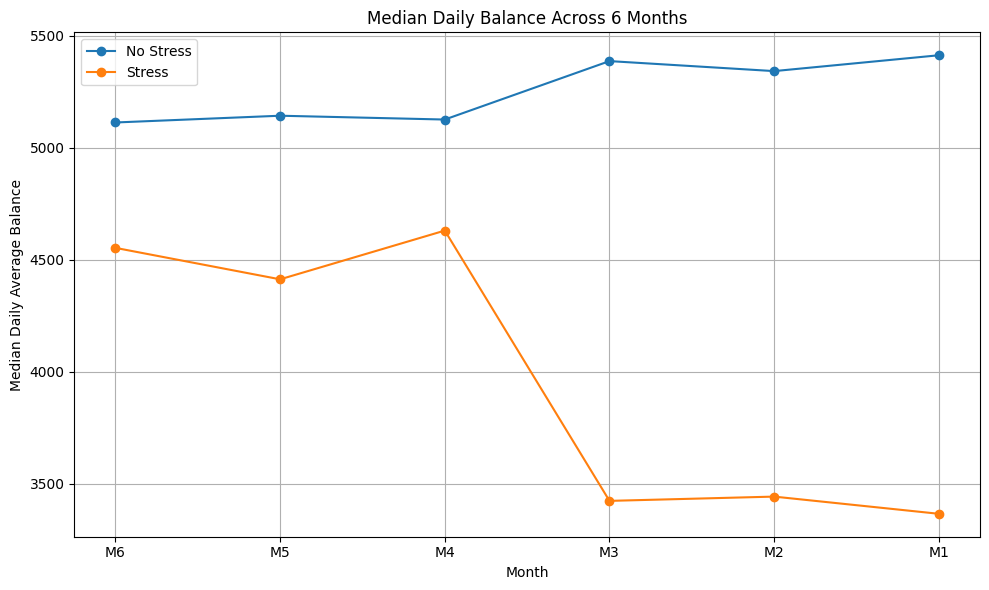

In [21]:
# Median balance trajectory

median_balance = train.groupby(target_col)[balance_cols].median()

months = ["M6", "M5", "M4", "M3", "M2", "M1"]

plt.figure(figsize=(10, 6))

plt.plot(
    months,
    median_balance.loc[0, balance_cols].values[::-1],
    marker="o",
    label="No Stress"
)

plt.plot(
    months,
    median_balance.loc[1, balance_cols].values[::-1],
    marker="o",
    label="Stress"
)

plt.title("Median Daily Balance Across 6 Months")
plt.xlabel("Month")
plt.ylabel("Median Daily Average Balance")
plt.legend()

plt.tight_layout()
plt.show()

In [22]:
# ============================================
# CELL 14 — ACTIVITY RATE VS TARGET
# ============================================

activity_col = "x_90_d_activity_rate"

print(
    train.groupby(target_col)[activity_col]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .round(4)
)

                           count   mean  median    std    min    max
liquidity_stress_next_30d                                           
0                          34000 0.5082  0.5137 0.2273 0.0000 1.0000
1                           6000 0.4815  0.4740 0.2394 0.0000 1.0000


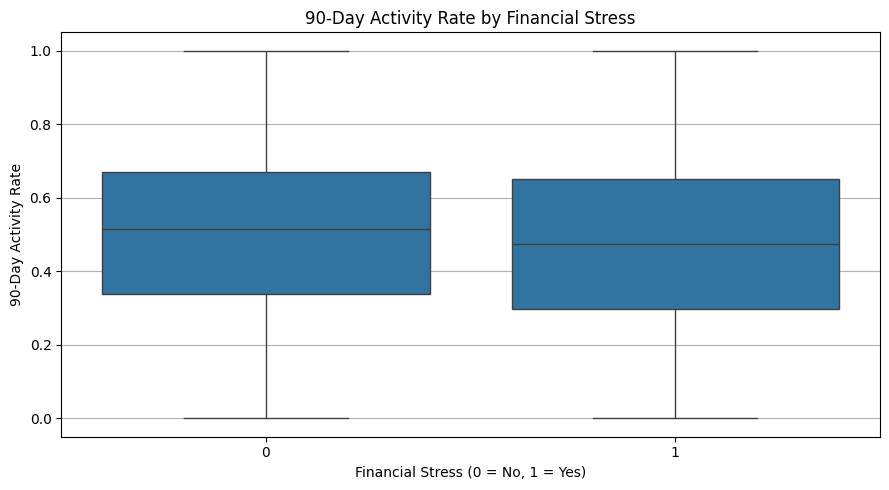

In [23]:
# Distribution of activity rate by target

plt.figure(figsize=(9, 5))

sns.boxplot(
    data=train,
    x=target_col,
    y=activity_col
)

plt.title("90-Day Activity Rate by Financial Stress")
plt.xlabel("Financial Stress (0 = No, 1 = Yes)")
plt.ylabel("90-Day Activity Rate")

plt.tight_layout()
plt.show()

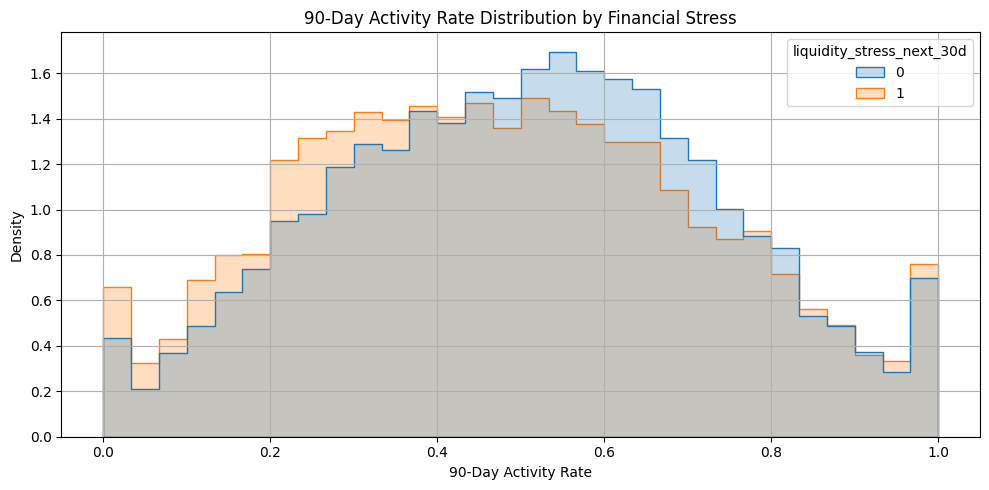

In [24]:
# Activity rate distribution

plt.figure(figsize=(10, 5))

sns.histplot(
    data=train,
    x=activity_col,
    hue=target_col,
    bins=30,
    stat="density",
    common_norm=False,
    element="step"
)

plt.title("90-Day Activity Rate Distribution by Financial Stress")
plt.xlabel("90-Day Activity Rate")
plt.ylabel("Density")

plt.tight_layout()
plt.show()

In [25]:
# ============================================
# CELL 15 — TRANSACTION TYPE SUMMARY
# ============================================

transaction_types = [
    "paybill",
    "merchantpay",
    "transfer_from_bank",
    "mm_send",
    "received",
    "deposit",
    "withdraw"
]

# Calculate total transaction value across all 6 months
transaction_value_summary = pd.DataFrame(index=train.index)

for tx in transaction_types:
    cols = [
        col for col in train.columns
        if col.startswith(("m1_", "m2_", "m3_", "m4_", "m5_", "m6_"))
        and tx in col
        and "total_value" in col
    ]

    transaction_value_summary[f"{tx}_6m_value"] = train[cols].sum(axis=1)

print("Created 6-month total-value summaries for:")

for col in transaction_value_summary.columns:
    print("-", col)

print("\nShape:", transaction_value_summary.shape)

Created 6-month total-value summaries for:
- paybill_6m_value
- merchantpay_6m_value
- transfer_from_bank_6m_value
- mm_send_6m_value
- received_6m_value
- deposit_6m_value
- withdraw_6m_value

Shape: (40000, 7)


In [26]:
# ============================================
# CELL 16 — TRANSACTION VALUE VS TARGET
# ============================================

transaction_analysis = transaction_value_summary.copy()
transaction_analysis[target_col] = train[target_col].values

transaction_summary = transaction_analysis.groupby(target_col).mean().T

transaction_summary.columns = ["No Stress (0)", "Stress (1)"]

print(transaction_summary.round(2))

                             No Stress (0)   Stress (1)
paybill_6m_value              193,378.8100 243,374.0600
merchantpay_6m_value          124,632.7000 154,190.9700
transfer_from_bank_6m_value   300,750.6700 335,047.3900
mm_send_6m_value              583,764.8400 745,173.3900
received_6m_value             519,726.4000 606,770.7200
deposit_6m_value              688,390.3500 776,448.7300
withdraw_6m_value             599,046.8200 738,694.5300


In [27]:
# Percentage difference: Stress vs No Stress

transaction_summary["difference_%"] = (
    (transaction_summary["Stress (1)"] -
     transaction_summary["No Stress (0)"])
    / transaction_summary["No Stress (0)"]
) * 100

print("\nPercentage difference (Stress vs No Stress):")
print(
    transaction_summary["difference_%"]
    .sort_values(ascending=False)
    .round(2)
)


Percentage difference (Stress vs No Stress):
mm_send_6m_value              27.6500
paybill_6m_value              25.8500
merchantpay_6m_value          23.7200
withdraw_6m_value             23.3100
received_6m_value             16.7500
deposit_6m_value              12.7900
transfer_from_bank_6m_value   11.4000
Name: difference_%, dtype: float64


In [28]:
# ============================================
# CELL 17 — MM SEND MONTHLY TREND
# ============================================

mm_send_cols = [
    f"m{i}_mm_send_total_value"
    for i in range(1, 7)
]

mm_send_monthly = train.groupby(target_col)[mm_send_cols].mean().T

mm_send_monthly.columns = ["No Stress (0)", "Stress (1)"]

# Reverse order so oldest → most recent
mm_send_monthly = mm_send_monthly.iloc[::-1]

print(mm_send_monthly.round(2))

                        No Stress (0)   Stress (1)
m6_mm_send_total_value    96,878.3300 127,986.4200
m5_mm_send_total_value    97,720.2300 126,639.2400
m4_mm_send_total_value    99,487.9600 117,862.7600
m3_mm_send_total_value    95,461.8100 128,973.1700
m2_mm_send_total_value    97,032.2200 122,665.8900
m1_mm_send_total_value    97,184.2900 121,045.9000


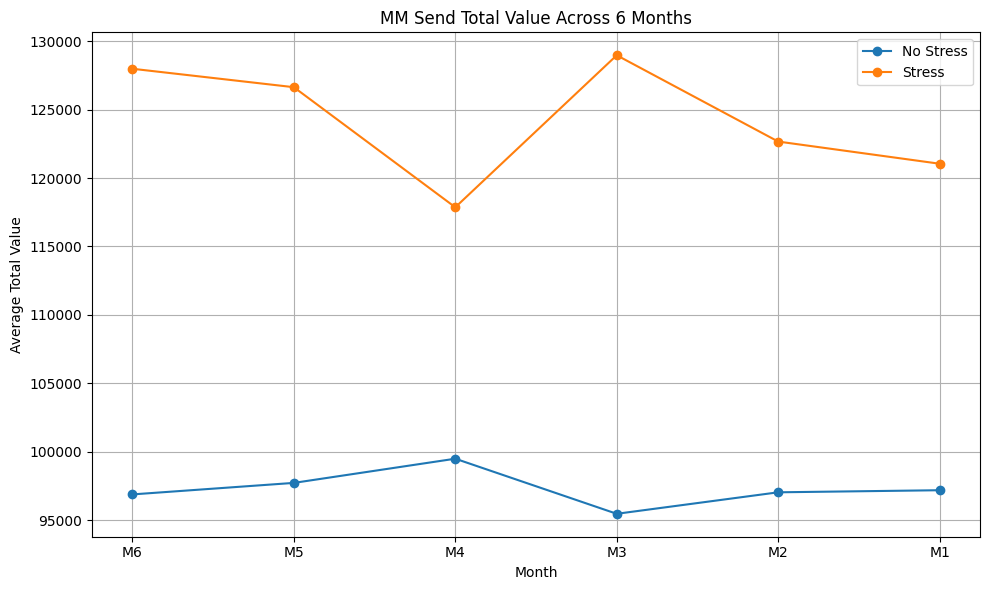

In [29]:
# Plot monthly MM Send behaviour

plt.figure(figsize=(10, 6))

plt.plot(
    ["M6", "M5", "M4", "M3", "M2", "M1"],
    mm_send_monthly["No Stress (0)"],
    marker="o",
    label="No Stress"
)

plt.plot(
    ["M6", "M5", "M4", "M3", "M2", "M1"],
    mm_send_monthly["Stress (1)"],
    marker="o",
    label="Stress"
)

plt.title("MM Send Total Value Across 6 Months")
plt.xlabel("Month")
plt.ylabel("Average Total Value")
plt.legend()

plt.tight_layout()
plt.show()

In [30]:
# ============================================
# CELL 18 — WITHDRAWAL & DEPOSIT TRENDS
# ============================================

withdraw_cols = [
    f"m{i}_withdraw_total_value"
    for i in range(1, 7)
]

deposit_cols = [
    f"m{i}_deposit_total_value"
    for i in range(1, 7)
]

# Average monthly values by target
withdraw_monthly = train.groupby(target_col)[withdraw_cols].mean().T
deposit_monthly = train.groupby(target_col)[deposit_cols].mean().T

withdraw_monthly.columns = ["No Stress (0)", "Stress (1)"]
deposit_monthly.columns = ["No Stress (0)", "Stress (1)"]

# Oldest → most recent
withdraw_monthly = withdraw_monthly.iloc[::-1]
deposit_monthly = deposit_monthly.iloc[::-1]

print("WITHDRAWAL")
print(withdraw_monthly.round(2))

print("\nDEPOSIT")
print(deposit_monthly.round(2))

WITHDRAWAL
                         No Stress (0)   Stress (1)
m6_withdraw_total_value   101,021.5300 113,025.5900
m5_withdraw_total_value   101,645.3800 116,998.7900
m4_withdraw_total_value   101,541.1800 129,310.0400
m3_withdraw_total_value    98,128.7800 128,336.8900
m2_withdraw_total_value    98,066.8400 121,640.7500
m1_withdraw_total_value    98,643.1100 129,382.4600

DEPOSIT
                        No Stress (0)   Stress (1)
m6_deposit_total_value   110,957.8800 144,018.6200
m5_deposit_total_value   113,021.9500 153,630.5900
m4_deposit_total_value   110,844.5400 151,267.0000
m3_deposit_total_value   119,473.5200 112,949.1200
m2_deposit_total_value   117,289.0900 104,133.8800
m1_deposit_total_value   116,803.3900 110,449.5200


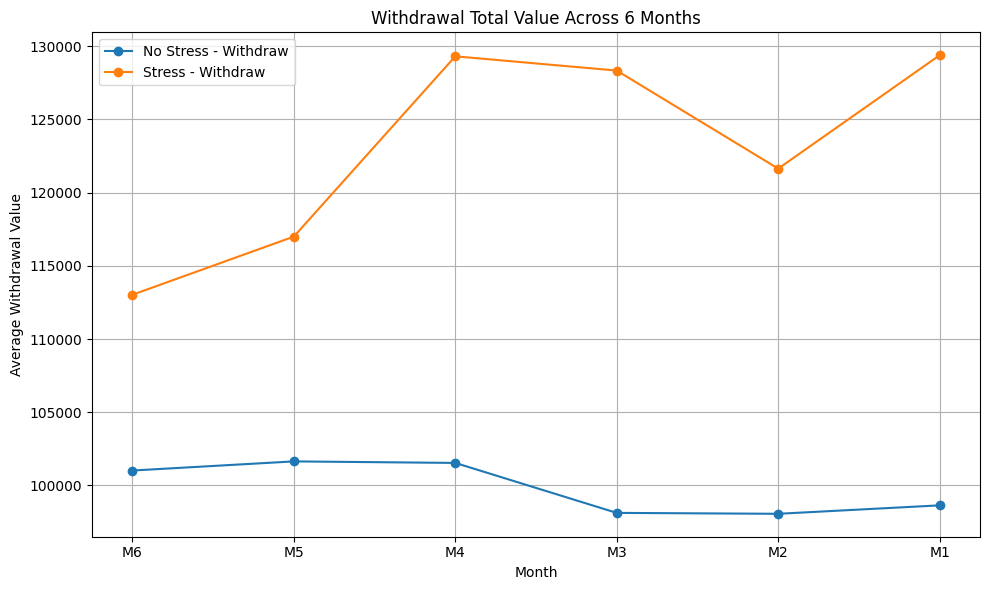

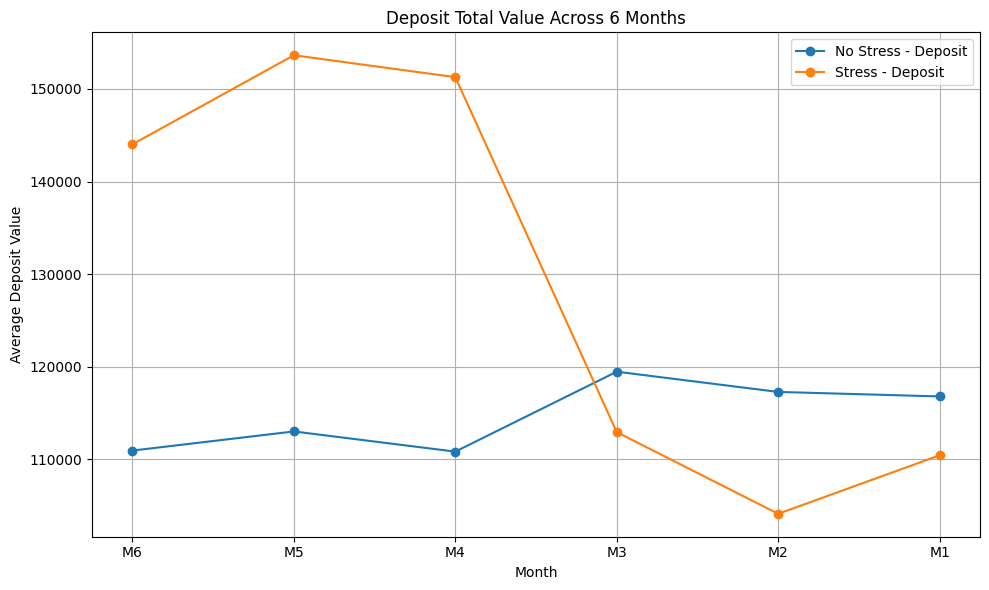

In [31]:
# ============================================
# VISUALIZE WITHDRAWAL & DEPOSIT
# ============================================

months = ["M6", "M5", "M4", "M3", "M2", "M1"]

plt.figure(figsize=(10, 6))

plt.plot(
    months,
    withdraw_monthly["No Stress (0)"],
    marker="o",
    label="No Stress - Withdraw"
)

plt.plot(
    months,
    withdraw_monthly["Stress (1)"],
    marker="o",
    label="Stress - Withdraw"
)

plt.title("Withdrawal Total Value Across 6 Months")
plt.xlabel("Month")
plt.ylabel("Average Withdrawal Value")
plt.legend()

plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 6))

plt.plot(
    months,
    deposit_monthly["No Stress (0)"],
    marker="o",
    label="No Stress - Deposit"
)

plt.plot(
    months,
    deposit_monthly["Stress (1)"],
    marker="o",
    label="Stress - Deposit"
)

plt.title("Deposit Total Value Across 6 Months")
plt.xlabel("Month")
plt.ylabel("Average Deposit Value")
plt.legend()

plt.tight_layout()
plt.show()


                        No Stress (0)   Stress (1)
m6_deposit_total_value   110,957.8800 144,018.6200
m5_deposit_total_value   113,021.9500 153,630.5900
m4_deposit_total_value   110,844.5400 151,267.0000
m3_deposit_total_value   119,473.5200 112,949.1200
m2_deposit_total_value   117,289.0900 104,133.8800
m1_deposit_total_value   116,803.3900 110,449.5200


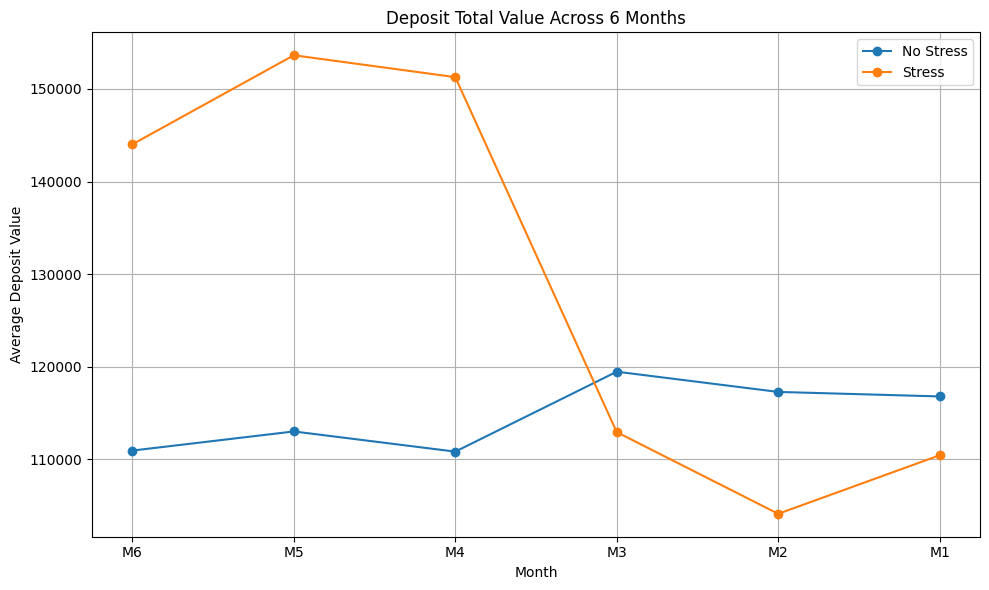

In [32]:
# ============================================
# CELL 19 — DEPOSIT TREND
# ============================================

deposit_cols = [
    f"m{i}_deposit_total_value"
    for i in range(1, 7)
]

deposit_monthly = train.groupby(target_col)[deposit_cols].mean().T
deposit_monthly.columns = ["No Stress (0)", "Stress (1)"]

# Oldest → most recent
deposit_monthly = deposit_monthly.iloc[::-1]

print(deposit_monthly.round(2))

# Plot
months = ["M6", "M5", "M4", "M3", "M2", "M1"]

plt.figure(figsize=(10, 6))

plt.plot(
    months,
    deposit_monthly["No Stress (0)"],
    marker="o",
    label="No Stress"
)

plt.plot(
    months,
    deposit_monthly["Stress (1)"],
    marker="o",
    label="Stress"
)

plt.title("Deposit Total Value Across 6 Months")
plt.xlabel("Month")
plt.ylabel("Average Deposit Value")
plt.legend()

plt.tight_layout()
plt.show()

In [33]:
# ============================================
# CELL 20 — WITHDRAWAL / DEPOSIT RATIO
# ============================================

# Six-month total withdrawal and deposit values
withdraw_total = train[withdraw_cols].sum(axis=1)
deposit_total = train[deposit_cols].sum(axis=1)

# Avoid division by zero
withdraw_deposit_ratio = withdraw_total / (deposit_total + 1)

# Compare the ratio between the two target groups
ratio_summary = train.assign(
    withdraw_deposit_ratio=withdraw_deposit_ratio
).groupby(target_col)["withdraw_deposit_ratio"].agg(
    ["count", "mean", "median", "std", "min", "max"]
)

print(ratio_summary.round(4))

                           count       mean  median         std    min  \
liquidity_stress_next_30d                                                
0                          34000   395.2276  0.8661 10,430.8051 0.0000   
1                           6000 1,120.9886  1.0837 19,887.2117 0.0000   

                                   max  
liquidity_stress_next_30d               
0                         558,474.5000  
1                         784,116.3300  


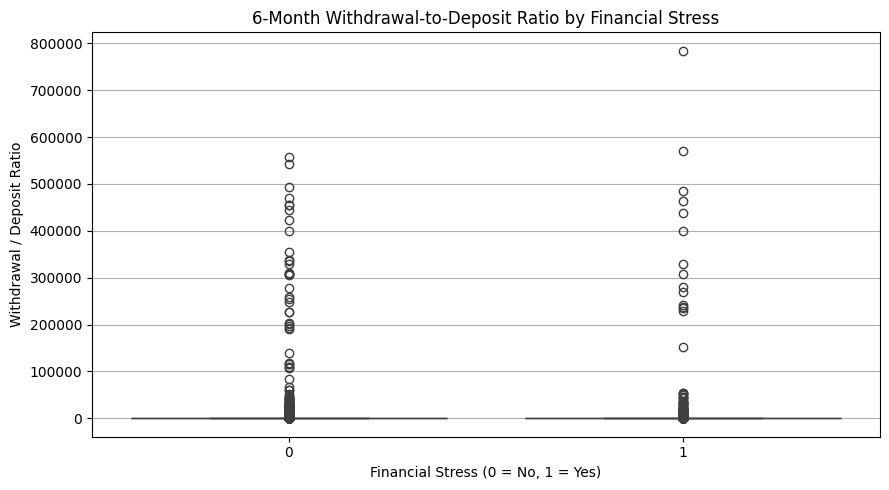

In [34]:
# Visualize the ratio

plt.figure(figsize=(9, 5))

sns.boxplot(
    x=train[target_col],
    y=withdraw_deposit_ratio
)

plt.title("6-Month Withdrawal-to-Deposit Ratio by Financial Stress")
plt.xlabel("Financial Stress (0 = No, 1 = Yes)")
plt.ylabel("Withdrawal / Deposit Ratio")

plt.tight_layout()
plt.show()

In [35]:
# ============================================
# CELL 21 — ROBUST WITHDRAWAL/DEPOSIT ANALYSIS
# ============================================

ratio_df = pd.DataFrame({
    "ratio": withdraw_deposit_ratio,
    "target": train[target_col]
})

# Robust statistics
ratio_stats = ratio_df.groupby("target")["ratio"].quantile(
    [0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
).unstack()

ratio_stats.index = ["No Stress (0)", "Stress (1)"]

print("Withdrawal / Deposit Ratio Quantiles:")
print(ratio_stats.round(3))


Withdrawal / Deposit Ratio Quantiles:
               0.2500  0.5000  0.7500  0.9000  0.9500      0.9900
No Stress (0)  0.4440  0.8660  1.6720  3.1620  4.8220     16.0460
Stress (1)     0.5270  1.0840  2.2570  4.6690  8.3780 10,566.8090


In [36]:
# Log transformation
ratio_df["log_ratio"] = np.log1p(ratio_df["ratio"])

print("\nLog-transformed ratio statistics:")
print(
    ratio_df.groupby("target")["log_ratio"]
    .agg(["mean", "median", "std", "min", "max"])
    .round(3)
)


Log-transformed ratio statistics:
         mean  median    std    min     max
target                                     
0      0.7880  0.6240 0.8810 0.0000 13.2330
1      0.9920  0.7340 1.2550 0.0000 13.5720


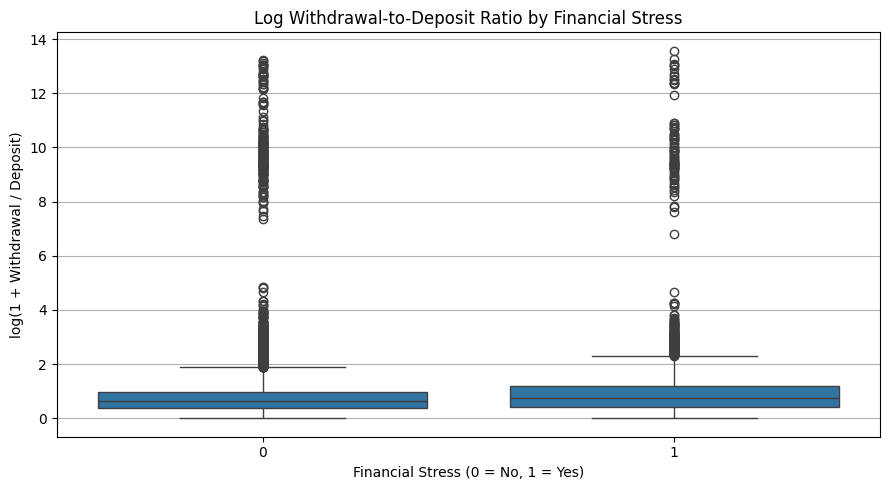

In [37]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=ratio_df,
    x="target",
    y="log_ratio"
)

plt.title("Log Withdrawal-to-Deposit Ratio by Financial Stress")
plt.xlabel("Financial Stress (0 = No, 1 = Yes)")
plt.ylabel("log(1 + Withdrawal / Deposit)")

plt.tight_layout()
plt.show()

In [38]:
# ============================================
# CELL 22 — START FEATURE ENGINEERING
# ============================================

# Keep original cleaned datasets untouched
train_fe = train.copy()
test_fe = test.copy()

print("Original Train shape:", train.shape)
print("Original Test shape:", test.shape)

print("\nFeature Engineering datasets created:")
print("train_fe:", train_fe.shape)
print("test_fe :", test_fe.shape)

Original Train shape: (40000, 184)
Original Test shape: (30000, 183)

Feature Engineering datasets created:
train_fe: (40000, 184)
test_fe : (30000, 183)


In [39]:
# ============================================
# CELL 23 — BALANCE ENGINEERED FEATURES
# ============================================

def add_balance_features(df):
    df = df.copy()

    # Monthly balance columns
    m1 = df["m1_daily_avg_bal"]
    m2 = df["m2_daily_avg_bal"]
    m3 = df["m3_daily_avg_bal"]
    m4 = df["m4_daily_avg_bal"]
    m5 = df["m5_daily_avg_bal"]
    m6 = df["m6_daily_avg_bal"]

    # 1. Overall change: oldest → most recent
    df["balance_change_M6_M1"] = m1 - m6

    # 2. Important transition identified during EDA
    df["balance_change_M4_M3"] = m3 - m4

    # 3. Recent average balance
    df["recent_avg_balance"] = (m1 + m2) / 2

    # 4. Historical average balance
    df["historical_avg_balance"] = (m3 + m4 + m5 + m6) / 4

    # 5. Recent vs historical difference
    df["recent_vs_historical_balance"] = (
        df["recent_avg_balance"] - df["historical_avg_balance"]
    )

    # 6. Six-month balance volatility
    df["balance_std_6m"] = df[
        [
            "m1_daily_avg_bal",
            "m2_daily_avg_bal",
            "m3_daily_avg_bal",
            "m4_daily_avg_bal",
            "m5_daily_avg_bal",
            "m6_daily_avg_bal"
        ]
    ].std(axis=1)

    return df


train_fe = add_balance_features(train_fe)
test_fe = add_balance_features(test_fe)

print("Train shape:", train_fe.shape)
print("Test shape:", test_fe.shape)

print("\nNew balance features:")
new_balance_features = [
    "balance_change_M6_M1",
    "balance_change_M4_M3",
    "recent_avg_balance",
    "historical_avg_balance",
    "recent_vs_historical_balance",
    "balance_std_6m"
]

print(new_balance_features)

Train shape: (40000, 190)
Test shape: (30000, 189)

New balance features:
['balance_change_M6_M1', 'balance_change_M4_M3', 'recent_avg_balance', 'historical_avg_balance', 'recent_vs_historical_balance', 'balance_std_6m']


In [40]:
# ============================================
# CELL 24 — WITHDRAWAL & DEPOSIT FEATURES
# ============================================

def add_cashflow_features(df):
    df = df.copy()

    # Monthly withdrawal columns
    withdraw_cols = [
        f"m{i}_withdraw_total_value"
        for i in range(1, 7)
    ]

    # Monthly deposit columns
    deposit_cols = [
        f"m{i}_deposit_total_value"
        for i in range(1, 7)
    ]

    # 1. Six-month totals
    df["withdraw_total_6m"] = df[withdraw_cols].sum(axis=1)
    df["deposit_total_6m"] = df[deposit_cols].sum(axis=1)

    # 2. Recent 2-month totals
    df["withdraw_recent_2m"] = df[
        ["m1_withdraw_total_value", "m2_withdraw_total_value"]
    ].sum(axis=1)

    df["deposit_recent_2m"] = df[
        ["m1_deposit_total_value", "m2_deposit_total_value"]
    ].sum(axis=1)

    # 3. Historical 4-month totals
    df["withdraw_historical_4m"] = df[
        [
            "m3_withdraw_total_value",
            "m4_withdraw_total_value",
            "m5_withdraw_total_value",
            "m6_withdraw_total_value"
        ]
    ].sum(axis=1)

    df["deposit_historical_4m"] = df[
        [
            "m3_deposit_total_value",
            "m4_deposit_total_value",
            "m5_deposit_total_value",
            "m6_deposit_total_value"
        ]
    ].sum(axis=1)

    # 4. Recent vs historical withdrawal change
    df["withdraw_recent_vs_historical"] = (
        df["withdraw_recent_2m"] /
        (df["withdraw_historical_4m"] / 2 + 1)
    )

    # 5. Recent vs historical deposit change
    df["deposit_recent_vs_historical"] = (
        df["deposit_recent_2m"] /
        (df["deposit_historical_4m"] / 2 + 1)
    )

    # 6. Withdrawal-to-deposit ratio
    df["withdraw_deposit_ratio_6m"] = (
        df["withdraw_total_6m"] /
        (df["deposit_total_6m"] + 1)
    )

    # 7. Log-transformed ratio
    df["log_withdraw_deposit_ratio"] = np.log1p(
        df["withdraw_deposit_ratio_6m"]
    )

    # 8. Zero/near-zero deposit indicator
    df["low_deposit_6m"] = (
        df["deposit_total_6m"] <= 1
    ).astype(int)

    return df


train_fe = add_cashflow_features(train_fe)
test_fe = add_cashflow_features(test_fe)

print("Train shape:", train_fe.shape)
print("Test shape:", test_fe.shape)

print("\nNew cash-flow features:")
cashflow_features = [
    "withdraw_total_6m",
    "deposit_total_6m",
    "withdraw_recent_2m",
    "deposit_recent_2m",
    "withdraw_historical_4m",
    "deposit_historical_4m",
    "withdraw_recent_vs_historical",
    "deposit_recent_vs_historical",
    "withdraw_deposit_ratio_6m",
    "log_withdraw_deposit_ratio",
    "low_deposit_6m"
]

print(cashflow_features)

Train shape: (40000, 201)
Test shape: (30000, 200)

New cash-flow features:
['withdraw_total_6m', 'deposit_total_6m', 'withdraw_recent_2m', 'deposit_recent_2m', 'withdraw_historical_4m', 'deposit_historical_4m', 'withdraw_recent_vs_historical', 'deposit_recent_vs_historical', 'withdraw_deposit_ratio_6m', 'log_withdraw_deposit_ratio', 'low_deposit_6m']


In [41]:
# ============================================
# CELL 25 — OVERALL TRANSACTION FEATURES
# ============================================

transaction_types = [
    "paybill",
    "merchantpay",
    "transfer_from_bank",
    "mm_send",
    "received",
    "deposit",
    "withdraw"
]


def add_transaction_features(df):
    df = df.copy()

    # ----------------------------------------
    # 1. Total transaction VALUE across
    #    all transaction types and 6 months
    # ----------------------------------------
    value_cols = [
        col for col in df.columns
        if any(tx in col for tx in transaction_types)
        and "total_value" in col
        and col.startswith(("m1_", "m2_", "m3_", "m4_", "m5_", "m6_"))
    ]

    df["total_transaction_value_6m"] = df[value_cols].sum(axis=1)

    # ----------------------------------------
    # 2. Total transaction VOLUME
    # ----------------------------------------
    volume_cols = [
        col for col in df.columns
        if any(tx in col for tx in transaction_types)
        and "volume" in col
        and col.startswith(("m1_", "m2_", "m3_", "m4_", "m5_", "m6_"))
    ]

    df["total_transaction_volume_6m"] = df[volume_cols].sum(axis=1)

    # ----------------------------------------
    # 3. Average transaction value
    # ----------------------------------------
    df["avg_transaction_value"] = (
        df["total_transaction_value_6m"] /
        (df["total_transaction_volume_6m"] + 1)
    )

    return df


train_fe = add_transaction_features(train_fe)
test_fe = add_transaction_features(test_fe)

print("Train shape:", train_fe.shape)
print("Test shape:", test_fe.shape)

print("\nNew features:")
print([
    "total_transaction_value_6m",
    "total_transaction_volume_6m",
    "avg_transaction_value"
])

Train shape: (40000, 204)
Test shape: (30000, 203)

New features:
['total_transaction_value_6m', 'total_transaction_volume_6m', 'avg_transaction_value']


In [42]:
# ============================================
# CELL 26 — RECENT VS HISTORICAL TRANSACTIONS
# ============================================

def add_transaction_trend_features(df):
    df = df.copy()

    transaction_types = [
        "paybill",
        "merchantpay",
        "transfer_from_bank",
        "mm_send",
        "received",
        "deposit",
        "withdraw"
    ]

    for tx in transaction_types:

        # Recent 2 months
        recent_cols = [
            f"m1_{tx}_total_value",
            f"m2_{tx}_total_value"
        ]

        # Historical 4 months
        historical_cols = [
            f"m3_{tx}_total_value",
            f"m4_{tx}_total_value",
            f"m5_{tx}_total_value",
            f"m6_{tx}_total_value"
        ]

        recent = df[recent_cols].sum(axis=1)
        historical = df[historical_cols].sum(axis=1)

        # Average monthly value: recent vs historical
        df[f"{tx}_recent_vs_historical"] = (
            (recent / 2) /
            (historical / 4 + 1)
        )

        # Overall 6-month average
        df[f"{tx}_avg_monthly_6m"] = (
            df[
                [
                    f"m1_{tx}_total_value",
                    f"m2_{tx}_total_value",
                    f"m3_{tx}_total_value",
                    f"m4_{tx}_total_value",
                    f"m5_{tx}_total_value",
                    f"m6_{tx}_total_value"
                ]
            ].sum(axis=1) / 6
        )

    return df


train_fe = add_transaction_trend_features(train_fe)
test_fe = add_transaction_trend_features(test_fe)

print("Train shape:", train_fe.shape)
print("Test shape:", test_fe.shape)

print("\nNumber of new transaction trend features:",
      7 * 2)

Train shape: (40000, 216)
Test shape: (30000, 215)

Number of new transaction trend features: 14


In [43]:
# ============================================
# CELL 27 — FEATURE SANITY CHECK
# ============================================

# Check for missing values
train_missing = train_fe.isna().sum().sum()
test_missing = test_fe.isna().sum().sum()

# Check for infinite values
train_inf = np.isinf(
    train_fe.select_dtypes(include=np.number)
).sum().sum()

test_inf = np.isinf(
    test_fe.select_dtypes(include=np.number)
).sum().sum()

print("Train missing values :", train_missing)
print("Test missing values  :", test_missing)

print("Train infinite values:", train_inf)
print("Test infinite values :", test_inf)

# Check feature alignment
train_features = set(train_fe.columns) - {target_col}
test_features = set(test_fe.columns)

print("\nTrain/Test feature sets identical:",
      train_features == test_features)

# Show newly created columns
original_train_cols = set(train.columns)

new_features = [
    col for col in train_fe.columns
    if col not in original_train_cols
]

print("\nNumber of engineered features:", len(new_features))

print("\nEngineered features:")
for col in new_features:
    print("-", col)

Train missing values : 0
Test missing values  : 0
Train infinite values: 0
Test infinite values : 0

Train/Test feature sets identical: True

Number of engineered features: 32

Engineered features:
- balance_change_M6_M1
- balance_change_M4_M3
- recent_avg_balance
- historical_avg_balance
- recent_vs_historical_balance
- balance_std_6m
- withdraw_total_6m
- deposit_total_6m
- withdraw_recent_2m
- deposit_recent_2m
- withdraw_historical_4m
- deposit_historical_4m
- withdraw_recent_vs_historical
- deposit_recent_vs_historical
- withdraw_deposit_ratio_6m
- log_withdraw_deposit_ratio
- low_deposit_6m
- total_transaction_value_6m
- total_transaction_volume_6m
- avg_transaction_value
- paybill_recent_vs_historical
- paybill_avg_monthly_6m
- merchantpay_recent_vs_historical
- merchantpay_avg_monthly_6m
- transfer_from_bank_recent_vs_historical
- transfer_from_bank_avg_monthly_6m
- mm_send_recent_vs_historical
- mm_send_avg_monthly_6m
- received_recent_vs_historical
- received_avg_monthly_6m
-

In [44]:
# ============================================
# CELL 28 — ENGINEERED FEATURE DIAGNOSTICS
# ============================================

from sklearn.metrics import roc_auc_score

feature_results = []

for feature in new_features:

    # Skip features with only one unique value
    if train_fe[feature].nunique() <= 1:
        continue

    auc = roc_auc_score(
        train_fe[target_col],
        train_fe[feature]
    )

    # AUC below 0.5 can still be informative in reverse
    auc_strength = max(auc, 1 - auc)

    feature_results.append({
        "feature": feature,
        "auc": auc,
        "auc_strength": auc_strength
    })

feature_results_df = (
    pd.DataFrame(feature_results)
    .sort_values("auc_strength", ascending=False)
)

print("Top engineered features by univariate AUC:")
print(
    feature_results_df.head(20).to_string(index=False)
)

Top engineered features by univariate AUC:
                                feature    auc  auc_strength
           recent_vs_historical_balance 0.3463        0.6537
           deposit_recent_vs_historical 0.3758        0.6242
                   balance_change_M6_M1 0.3823        0.6177
                   balance_change_M4_M3 0.3879        0.6121
                      deposit_recent_2m 0.4032        0.5968
          received_recent_vs_historical 0.4112        0.5888
                     recent_avg_balance 0.4235        0.5765
             log_withdraw_deposit_ratio 0.5622        0.5622
              withdraw_deposit_ratio_6m 0.5622        0.5622
          withdraw_recent_vs_historical 0.5581        0.5581
transfer_from_bank_recent_vs_historical 0.4489        0.5511
                 deposit_avg_monthly_6m 0.4502        0.5498
                       deposit_total_6m 0.4502        0.5498
                received_avg_monthly_6m 0.4523        0.5477
            total_transaction_volume_6m 0.

In [45]:
# ============================================
# CELL 29 — PREPARE FEATURES AND TARGET
# ============================================

target_col = "liquidity_stress_next_30d"

# Separate target
X = train_fe.drop(columns=[target_col])
y = train_fe[target_col]

X_test = test_fe.copy()

print("X shape      :", X.shape)
print("y shape      :", y.shape)
print("X_test shape:", X_test.shape)

print("\nTarget distribution:")
print(y.value_counts())
print(y.value_counts(normalize=True).round(4))

X shape      : (40000, 215)
y shape      : (40000,)
X_test shape: (30000, 215)

Target distribution:
liquidity_stress_next_30d
0    34000
1     6000
Name: count, dtype: int64
liquidity_stress_next_30d
0   0.8500
1   0.1500
Name: proportion, dtype: float64


In [46]:
# ============================================
# CELL 30 — STRATIFIED TRAIN / VALIDATION SPLIT
# ============================================

from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Training set:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nValidation set:")
print("X_valid:", X_valid.shape)
print("y_valid:", y_valid.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True).round(4))

print("\nValidation target distribution:")
print(y_valid.value_counts(normalize=True).round(4))

Training set:
X_train: (32000, 215)
y_train: (32000,)

Validation set:
X_valid: (8000, 215)
y_valid: (8000,)

Training target distribution:
liquidity_stress_next_30d
0   0.8500
1   0.1500
Name: proportion, dtype: float64

Validation target distribution:
liquidity_stress_next_30d
0   0.8500
1   0.1500
Name: proportion, dtype: float64


In [47]:
# ============================================
# CELL 31 — CATBOOST SETUP
# ============================================

!pip -q install catboost

from catboost import CatBoostClassifier

print("CatBoost imported successfully.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.9 MB/s eta 0:00:00
CatBoost imported successfully.


In [48]:
# ============================================
# CELL 32 — IDENTIFY CATEGORICAL FEATURES
# ============================================

categorical_cols = [
    "gender",
    "region",
    "smartphone",
    "segment",
    "earning_pattern"
]

# Verify that all categorical columns exist
missing_categorical = [
    col for col in categorical_cols
    if col not in X_train.columns
]

print("Categorical columns:")
for col in categorical_cols:
    print("-", col)

print("\nMissing categorical columns:", missing_categorical)

# Convert categorical columns to string
for col in categorical_cols:
    X_train[col] = X_train[col].astype(str)
    X_valid[col] = X_valid[col].astype(str)
    X_test[col] = X_test[col].astype(str)

print("\nCategorical columns converted to string.")

Categorical columns:
- gender
- region
- smartphone
- segment
- earning_pattern

Missing categorical columns: []

Categorical columns converted to string.


In [49]:
# ============================================
# CELL 33 — CATBOOST BASELINE MODEL
# ============================================

cat_features = [
    X_train.columns.get_loc(col)
    for col in categorical_cols
]

model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function="Logloss",
    eval_metric="Logloss",
    random_seed=42,
    verbose=100,
    allow_writing_files=False
)

model.fit(
    X_train,
    y_train,
    cat_features=cat_features,
    eval_set=(X_valid, y_valid),
    early_stopping_rounds=50
)

print("\nCatBoost training completed.")

CatBoostError: Bad value for num_feature[non_default_doc_idx=0,feature_idx=182]="ID_183EACB4F6": Cannot convert 'ID_183EACB4F6' to float

In [50]:
# ============================================
# CELL 33 — PREPARE MODEL DATA + CATBOOST
# ============================================

# Remove ID from model features
X_train_model = X_train.drop(columns=["ID"]).copy()
X_valid_model = X_valid.drop(columns=["ID"]).copy()
X_test_model = X_test.drop(columns=["ID"]).copy()

# Find categorical feature positions AFTER removing ID
cat_features = [
    X_train_model.columns.get_loc(col)
    for col in categorical_cols
]

print("Training features:", X_train_model.shape)
print("Validation features:", X_valid_model.shape)
print("Test features:", X_test_model.shape)

print("\nID present in model data:",
      "ID" in X_train_model.columns)

print("\nCategorical feature indices:", cat_features)


# --------------------------------------------
# CatBoost model
# --------------------------------------------

model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function="Logloss",
    eval_metric="Logloss",
    random_seed=42,
    verbose=100,
    allow_writing_files=False
)

model.fit(
    X_train_model,
    y_train,
    cat_features=cat_features,
    eval_set=(X_valid_model, y_valid),
    early_stopping_rounds=50
)

print("\nCatBoost training completed.")

Training features: (32000, 214)
Validation features: (8000, 214)
Test features: (30000, 214)

ID present in model data: False

Categorical feature indices: [2, 3, 4, 5, 6]
0:	learn: 0.6600253	test: 0.6604726	best: 0.6604726 (0)	total: 117ms	remaining: 58.4s
100:	learn: 0.3033326	test: 0.3227646	best: 0.3227646 (100)	total: 9.58s	remaining: 37.8s
200:	learn: 0.2725309	test: 0.3027998	best: 0.3027998 (200)	total: 20.4s	remaining: 30.3s
300:	learn: 0.2495759	test: 0.2912263	best: 0.2912263 (300)	total: 28.9s	remaining: 19.1s
400:	learn: 0.2320382	test: 0.2854906	best: 0.2854906 (400)	total: 38.3s	remaining: 9.46s
499:	learn: 0.2172288	test: 0.2812436	best: 0.2812096 (496)	total: 47.3s	remaining: 0us

bestTest = 0.2812096281
bestIteration = 496

Shrink model to first 497 iterations.

CatBoost training completed.


In [51]:
# ============================================
# CELL 34 — VALIDATION METRICS
# ============================================

from sklearn.metrics import log_loss, roc_auc_score

# Predict probability of class 1
valid_pred = model.predict_proba(X_valid_model)[:, 1]

# Calculate metrics
valid_logloss = log_loss(y_valid, valid_pred)
valid_rocauc = roc_auc_score(y_valid, valid_pred)

print("Validation Results")
print("=" * 40)

print(f"Log Loss : {valid_logloss:.6f}")
print(f"ROC-AUC  : {valid_rocauc:.6f}")

Validation Results
Log Loss : 0.281210
ROC-AUC  : 0.880365


In [52]:
# ============================================
# CELL 35 — CATBOOST FEATURE IMPORTANCE
# ============================================

feature_importance = pd.DataFrame({
    "feature": X_train_model.columns,
    "importance": model.get_feature_importance()
})

feature_importance = (
    feature_importance
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

print("Top 30 features:")
print(feature_importance.head(30).to_string(index=False))

Top 30 features:
                                feature  importance
           recent_vs_historical_balance      9.8593
           deposit_recent_vs_historical      5.5265
                       m3_daily_avg_bal      5.2665
                   balance_change_M4_M3      4.3337
          received_recent_vs_historical      3.7384
                 m3_deposit_total_value      3.6004
                m3_received_total_value      2.5147
                   balance_change_M6_M1      2.3910
                      deposit_recent_2m      2.2644
                       m5_daily_avg_bal      2.1184
transfer_from_bank_recent_vs_historical      2.0154
                         balance_std_6m      2.0123
             m5_withdraw_highest_amount      1.9042
          withdraw_recent_vs_historical      1.8488
             m4_withdraw_highest_amount      1.6536
           paybill_recent_vs_historical      1.3491
                     recent_avg_balance      1.2383
                received_avg_monthly_6m      1.

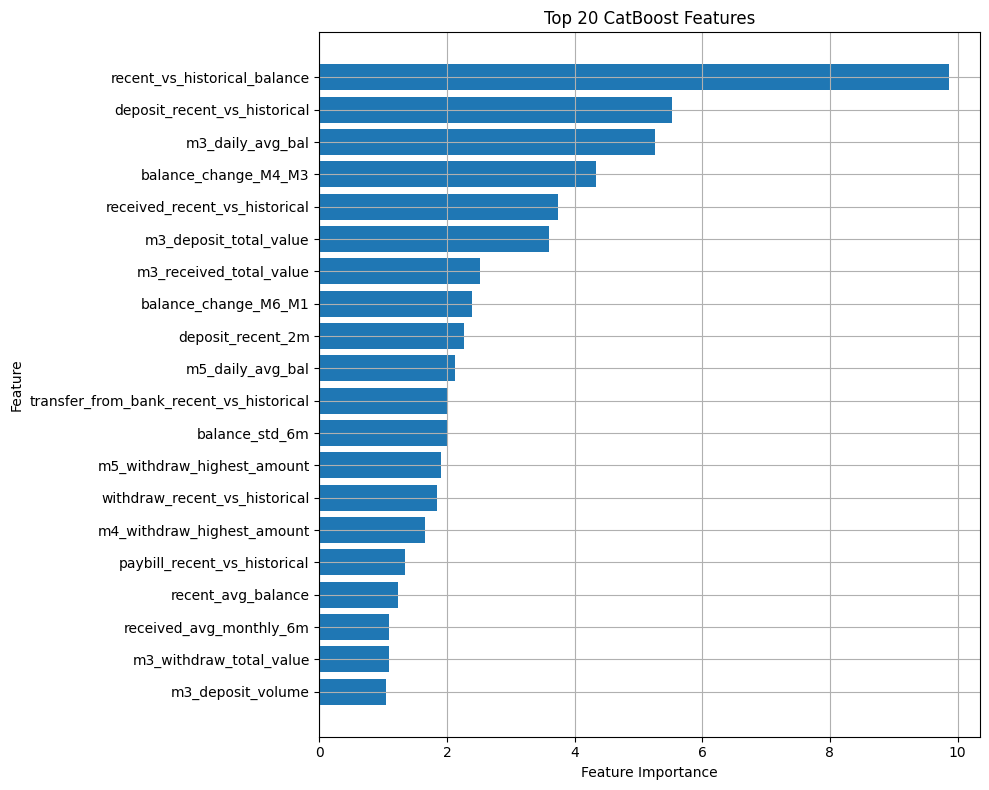

In [53]:
# ============================================
# TOP 20 FEATURE IMPORTANCE
# ============================================

top20 = feature_importance.head(20).sort_values("importance")

plt.figure(figsize=(10, 8))

plt.barh(
    top20["feature"],
    top20["importance"]
)

plt.title("Top 20 CatBoost Features")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [54]:
# ============================================
# CELL 36 — CATBOOST TUNED EXPERIMENT
# ============================================

tuned_model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.03,
    depth=7,
    loss_function="Logloss",
    eval_metric="Logloss",
    random_seed=42,
    l2_leaf_reg=5,
    random_strength=1,
    verbose=200,
    allow_writing_files=False
)

tuned_model.fit(
    X_train_model,
    y_train,
    cat_features=cat_features,
    eval_set=(X_valid_model, y_valid),
    early_stopping_rounds=100
)

print("\nTuned CatBoost training completed.")

0:	learn: 0.6723298	test: 0.6725932	best: 0.6725932 (0)	total: 108ms	remaining: 1m 47s
200:	learn: 0.2847120	test: 0.3129526	best: 0.3129526 (200)	total: 24.4s	remaining: 1m 36s
400:	learn: 0.2474596	test: 0.2936535	best: 0.2936535 (400)	total: 48.1s	remaining: 1m 11s
600:	learn: 0.2184870	test: 0.2842527	best: 0.2842527 (600)	total: 1m 10s	remaining: 47.1s
800:	learn: 0.1981967	test: 0.2801265	best: 0.2801104 (799)	total: 1m 33s	remaining: 23.2s
999:	learn: 0.1839439	test: 0.2774693	best: 0.2774693 (999)	total: 1m 53s	remaining: 0us

bestTest = 0.2774692735
bestIteration = 999


Tuned CatBoost training completed.


In [55]:
# ============================================
# CELL 37 — TUNED MODEL VALIDATION METRICS
# ============================================

tuned_valid_pred = tuned_model.predict_proba(
    X_valid_model
)[:, 1]

tuned_logloss = log_loss(
    y_valid,
    tuned_valid_pred
)

tuned_rocauc = roc_auc_score(
    y_valid,
    tuned_valid_pred
)

print("Tuned CatBoost Validation Results")
print("=" * 45)

print(f"Log Loss : {tuned_logloss:.6f}")
print(f"ROC-AUC  : {tuned_rocauc:.6f}")

Tuned CatBoost Validation Results
Log Loss : 0.277469
ROC-AUC  : 0.882832


In [56]:
# ============================================
# CELL 38 — FINAL MODEL ON ALL TRAIN DATA
# ============================================

final_model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.03,
    depth=7,
    loss_function="Logloss",
    random_seed=42,
    l2_leaf_reg=5,
    random_strength=1,
    verbose=200,
    allow_writing_files=False
)

final_model.fit(
    X.drop(columns=["ID"]),
    y,
    cat_features=cat_features
)

print("\nFinal model trained on all 40,000 training rows.")

0:	learn: 0.6702767	total: 112ms	remaining: 1m 51s
200:	learn: 0.2889031	total: 26.8s	remaining: 1m 46s
400:	learn: 0.2543442	total: 54s	remaining: 1m 20s
600:	learn: 0.2287738	total: 1m 19s	remaining: 52.9s
800:	learn: 0.2086923	total: 1m 46s	remaining: 26.5s
999:	learn: 0.1921849	total: 2m 11s	remaining: 0us

Final model trained on all 40,000 training rows.


In [57]:
# ============================================
# CELL 39 — GENERATE TEST PREDICTIONS
# ============================================

test_pred = final_model.predict_proba(
    X_test_model
)[:, 1]

print("Predictions generated successfully.")

print("\nNumber of predictions:", len(test_pred))

print("\nFirst 10 predictions:")
print(test_pred[:10])

print("\nPrediction range:")
print("Minimum:", test_pred.min())
print("Maximum:", test_pred.max())

Predictions generated successfully.

Number of predictions: 30000

First 10 predictions:
[0.02359475 0.08809374 0.03397665 0.01068244 0.02199955 0.22614782
 0.01759705 0.07208556 0.1010136  0.02530746]

Prediction range:
Minimum: 0.001868839823433739
Maximum: 0.995786877656641


In [58]:
# ============================================
# CELL 40 — CREATE ZINDI SUBMISSION #2
# ============================================

submission_02 = pd.DataFrame({
    "ID": test_fe["ID"],
    "Target": test_pred
})

# Save CSV
submission_02.to_csv(
    "submission_02.csv",
    index=False
)

print("Submission created successfully.")
print("Shape:", submission_02.shape)

print("\nFirst 10 rows:")
display(submission_02.head(10))

print("\nColumns:")
print(submission_02.columns.tolist())

Submission created successfully.
Shape: (30000, 2)

First 10 rows:


,ID,Target
0,ID_ED91AC7A28,0.0236
1,ID_29975A9C7E,0.0881
2,ID_F59CE25650,0.0340
3,ID_E875F68D1A,0.0107
4,ID_2902B1C0D0,0.0220
5,ID_8C3311150A,0.2261
6,ID_E7E3D1F707,0.0176
7,ID_0883F8130C,0.0721
8,ID_E6D3162C31,0.1010
9,ID_0E8F96135D,0.0253



Columns:
['ID', 'Target']


In [59]:
# ============================================
# FINAL SUBMISSION CHECK
# ============================================

print("Rows:", len(submission_02))
print("Columns:", submission_02.columns.tolist())

print("\nMissing values:")
print(submission_02.isna().sum())

print("\nDuplicate IDs:", submission_02["ID"].duplicated().sum())

print("\nPrediction range:")
print(submission_02["Target"].min(), "to", submission_02["Target"].max())

print("\nSubmission ready:",
      len(submission_02) == 30000
      and submission_02.columns.tolist() == ["ID", "Target"]
      and submission_02["ID"].duplicated().sum() == 0
      and submission_02["Target"].isna().sum() == 0
)

Rows: 30000
Columns: ['ID', 'Target']

Missing values:
ID        0
Target    0
dtype: int64

Duplicate IDs: 0

Prediction range:
0.001868839823433739 to 0.995786877656641

Submission ready: True


In [60]:
from google.colab import files

files.download("submission_02.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>